In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

df = pd.read_csv("Housing.csv")
print(df.head())

Saving Housing.csv to Housing.csv
User uploaded file "Housing.csv" with length 29981 bytes
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


### Data Preprocessing for SVM

Before building the SVM model, we need to preprocess the data. This involves:
1.  **Encoding Categorical Features**: Convert 'yes'/'no' columns to 1/0 and 'furnishingstatus' using one-hot encoding.
2.  **Splitting Data**: Separate features (X) from the target (y) and then split into training and testing sets.
3.  **Feature Scaling**: Scale numerical features to ensure they contribute equally to the model training, as SVMs are sensitive to the scale of features.

In [4]:

varlist = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']


def binary_map(x):
    return x.map({'yes': 1, 'no': 0})

df[varlist] = df[varlist].apply(binary_map)


furnishing_status_dummies = pd.get_dummies(df['furnishingstatus'], drop_first=True, dtype=int)
df = pd.concat([df, furnishing_status_dummies], axis=1)
df.drop('furnishingstatus', axis=1, inplace=True)

display(df.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [10]:
from sklearn.preprocessing import StandardScaler


X = df.drop('price', axis=1)
y = df['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (436, 13)
X_test shape: (109, 13)
y_train shape: (436,)
y_test shape: (109,)


### Build and Train SVM Model

Now we will use `sklearn.svm.SVR` to build and train the Support Vector Regressor model on the scaled training data.

In [12]:
from sklearn.svm import SVR


svm_model = SVR(kernel='rbf')
svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully with RBF kernel!")

SVM model trained successfully with RBF kernel!


### Evaluate SVM Model Performance

Finally, we will evaluate the trained SVM model using the test set and calculate evaluation metrics such as Mean Absolute Error (MAE) and R-squared ($R^2$).

In [13]:

y_pred_svm = svm_model.predict(X_test_scaled)


mae_svm = mean_absolute_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print(f"Mean Absolute Error (MAE) for SVM: {mae_svm:.2f}")
print(f"R-squared (R2) for SVM: {r2_svm:.2f}")

Mean Absolute Error (MAE) for SVM: 1763890.30
R-squared (R2) for SVM: -0.10


### Visualize SVM Predictions

Let's visualize the actual vs. predicted housing prices for the SVM model.

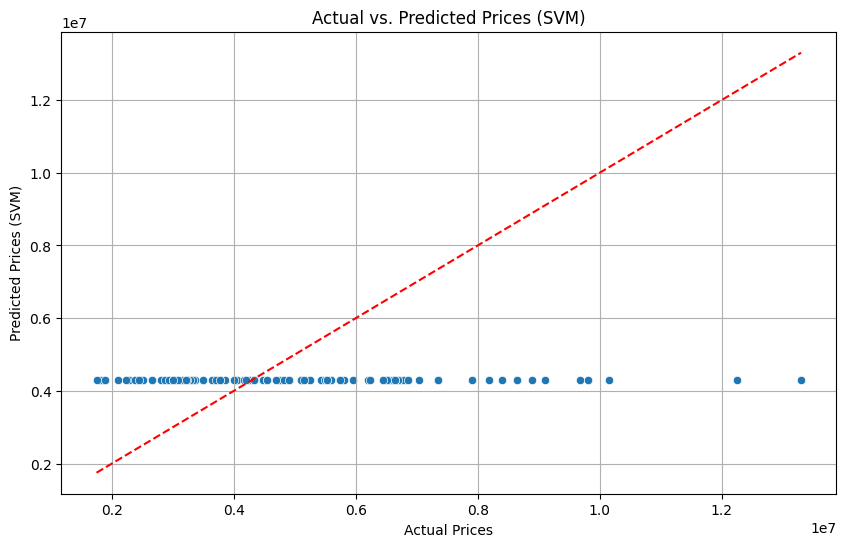

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_svm)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices (SVM)")
plt.title("Actual vs. Predicted Prices (SVM)")
plt.grid(True)
plt.show()

### Build and Train Linear Regression Model

Now, let's build and train a simple Linear Regression model to compare its performance with the SVM model.

In [14]:
from sklearn.linear_model import LinearRegression


linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


### Evaluate Linear Regression Model Performance

Let's evaluate the trained Linear Regression model using the test set and calculate evaluation metrics.

In [17]:

y_pred_lr = linear_model.predict(X_test_scaled)


mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Mean Absolute Error (MAE) for Linear Regression: {mae_lr:.2f}")
print(f"R-squared (R2) for Linear Regression: {r2_lr:.2f}")

Mean Absolute Error (MAE) for Linear Regression: 970043.40
R-squared (R2) for Linear Regression: 0.65


### Visualize Linear Regression Predictions

Let's visualize the actual vs. predicted housing prices for the Linear Regression model.

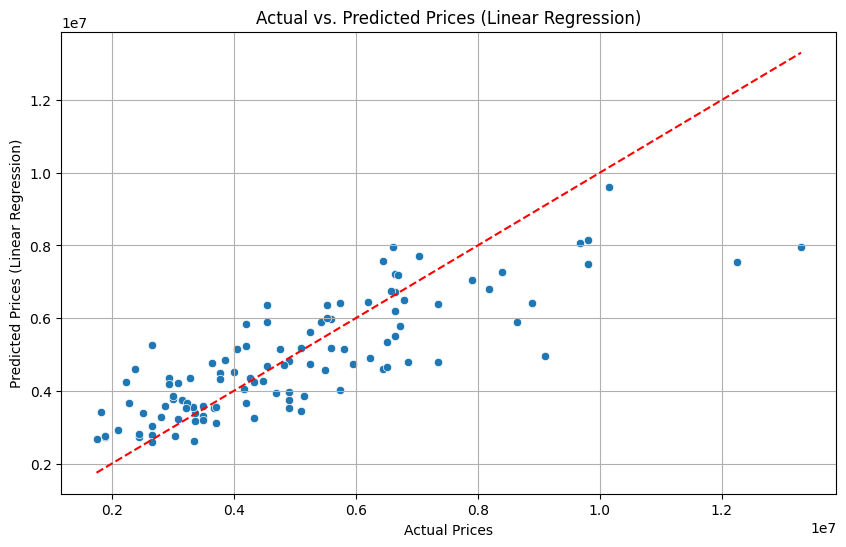

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices (Linear Regression)")
plt.title("Actual vs. Predicted Prices (Linear Regression)")
plt.grid(True)
plt.show()